In [1]:
import numpy as np
import xarray as xr
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import json
import cftime
from cftime import DatetimeNoLeap
from scipy import stats
from scipy.interpolate import interp1d
import dask
from tqdm import tqdm
from mpl_axes_aligner import align
from xmip.preprocessing import rename_cmip6
%matplotlib inline


from utils import QACC_utils
from utils.config import model, min_lat, max_lat, min_year_late_cent, max_year_late_cent

## Part 1
presave a set of needed variables, as arctic means

In [10]:
### define set of required variables, keep more than are needed here

rad_flux_vars_surface = ['rsds', 'rsus', 'rlds', 'rlus', 'rsdscs', 'rldscs']
# all radiative vars at surface

rad_flux_vars_TOA = ['rsdt', 'rsut', 'rlut', 'rlutcs', 'rsutcs', 'rsutaf', 'rsutcsaf']
# all radiative vars at top-of-atmosphere

heat_flux_vars_surface = ['hfls', 'hfss'] 
# surface upward latent heat flux and surface upward sensible heat flux

PE_vars = ['evspsbl', 'pr']
# precip and evap vars needed to distinguish sensible and latent heat

column_stored_energy_vars = ['ta', 'hus', 'hur']

additional = ['huss'] # might need the surface humidity for q feedback

# see Donohue et al 2020 JCLIM, equation A2 https://faculty.washington.edu/karmour/papers/Donohoe_etal_JCLIM2020.pdf

AHT_vars = ['tas'] + rad_flux_vars_surface + rad_flux_vars_TOA + heat_flux_vars_surface + PE_vars + additional # + column_stored_energy_vars


In [11]:

### preproces, a couple minutes:
scenarios = ['ssp245', 'ARISE']

for scen in scenarios:
    print(scen)
    ds = QACC_utils.get_all_vars_arctic_monthly(vars=AHT_vars, model=model,
                                      scenario=scen,
                                      min_lat=min_lat, max_lat=max_lat,
                                      min_year=min_year_late_cent, max_year=max_year_late_cent)
    ds = ds.compute()
    ds.to_netcdf('intermediate_outputs/init/{s}_{l}_{m}_singlelev.nc'.format(
        s=scen, l=str(min_lat), m=model))

ssp245


  0%|          | 0/19 [00:00<?, ?it/s]

tas


  5%|▌         | 1/19 [00:03<01:09,  3.86s/it]

rsds


...

 89%|████████▉ | 17/19 [00:30<00:03,  1.88s/it]

pr


 95%|█████████▍| 18/19 [00:32<00:01,  1.91s/it]

huss


100%|██████████| 19/19 [00:34<00:00,  1.80s/it]


In [6]:
## repeat for the variables on levels:
### preproces, a couple minutes:
scenarios = ['ssp245', 'ARISE']

for scen in scenarios:
    print(scen)
    ds = QACC_utils.get_all_vars_arctic_monthly(vars=column_stored_energy_vars, model=model,
                                      scenario=scen,
                                      min_lat=min_lat, max_lat=max_lat,
                                      min_year=min_year_late_cent, max_year=max_year_late_cent)
    ds = ds.compute()
    ds.to_netcdf('intermediate_outputs/init/{s}_{l}_{m}_alllevs.nc'.format(
        s=scen, l=str(min_lat), m=model))

ssp245


  0%|          | 0/3 [00:00<?, ?it/s]

ta


 33%|███▎      | 1/3 [00:05<00:10,  5.01s/it]

hus


...

 33%|███▎      | 1/3 [00:02<00:04,  2.24s/it]

hus


 67%|██████▋   | 2/3 [00:04<00:02,  2.47s/it]

hur


100%|██████████| 3/3 [00:07<00:00,  2.43s/it]


In [25]:
ds_ssp245 = xr.open_dataset('intermediate_outputs/init/{s}_{l}_{m}_singlelev.nc'.format(
            s='ssp245', l=str(min_lat), m=model))
ds_arise = xr.open_dataset('intermediate_outputs/init/{s}_{l}_{m}_singlelev.nc'.format(
            s='ARISE', l=str(min_lat), m=model))

ds_ssp245_al = xr.open_dataset('intermediate_outputs/init/{s}_{l}_{m}_alllevs.nc'.format(
            s='ssp245', l=str(min_lat), m=model))
ds_arise_al = xr.open_dataset('intermediate_outputs/init/{s}_{l}_{m}_alllevs.nc'.format(
            s='ARISE', l=str(min_lat), m=model))

ds_ssp245 = xr.merge([ds_ssp245, ds_ssp245_al], compat='override') # override necessary because of different number of ensemble members, which we saved as a var
ds_arise = xr.merge([ds_arise, ds_arise_al])

## Part 2
turn these into AHT, OHU, and other needed outputs

### Atmospheric heat Transport

Define a quantity, Q, as the residual from all energy budget terms above, for the pan-Arctic atmospheric column.

Q is equal to the sum of (1) AHT across boundary, and (2) change in energy stored in atmospheric column. 

or in my notation:

Q = AHT + d(S)/dt 

where S is the atmospheric stored energy, is equal to the integral over pressure levels of delta(cT + Lq)

In [26]:

# take Q as sum of energy leaving air column 
def get_Q(ds, units='W/m2'):
    
    if not units in ['W/m2', 'PW']: #check units
        print('Units must be set to either "W/m2" or "PW", default is W/m2') 
        
    ds = ds.mean('month')
    Q = (ds.rsds - ds.rsus + ds.rlds - ds.rlus - ds.hfls - ds.hfss + ds.rsut - ds.rsdt + ds.rlut)
   
    ### need to multiply by area to get these into total AHT units (PW)
    area = QACC_utils.get_surface_area_north_of_lat(min_lat)
    unit_conversions = {'W/m2':1,
                        'PW':area/(10**15)}
    ### now split into moist and dry components. Done following Hahn et al. 2021
    ### https://www.frontiersin.org/articles/10.3389/feart.2021.710036/full
    ### we take moist energy transport as (P-E)*(latent heat of vaporisation).
    ### this neglects the latent heat of fusion for solid precip. 
    ### the dry component is then calculated as the difference between Q and moist

    L = 2.501*(10**6)# latent heat of vaporisation, assumed constant at 2.501 × 10^6 J kg−1
    Qmoist = (ds.pr - ds.evspsbl)*L 

    Q = Q*unit_conversions[units] 
    Qmoist = Qmoist*unit_conversions[units]
        
    Qdry = Q - Qmoist
    return {'Q':Q.values*1, 'Qdry':Qdry.values*1, 'Qmoist':Qmoist.values*1}

def get_monthlyQ(ds, units='W/m2', account_for_storage=True):

    ## 'account_for_storage' makes no difference - delta_S is < 0.001 W/m2
    
    if not units in ['W/m2', 'PW']: #check units
        print('Units must be set to either "W/m2" or "PW", default is W/m2') 
    
    ### need to multiply by area to get these into total AHT units (PW)
    area = QACC_utils.get_surface_area_north_of_lat(min_lat)
    unit_conversions = {'W/m2':1,
                        'PW':area/(10**15)}

    
    # Constants
    c_p = 1004        # J/(kg·K), specific heat of dry air
    g = 9.81         # m/s², gravity
    L = 2.5e6       # J/kg, latent heat of vaporization
    seconds_per_month = 2.592e6 
    S = (1/g) * (c_p*ds_ssp245.ta.sum('plev') + L*ds_ssp245.hus.sum('plev')) * (1/seconds_per_month)
    delta_S = S - S.roll(month=1)

    if account_for_storage:
        ds['Q'] = (ds.rsds - ds.rsus + ds.rlds - ds.rlus - ds.hfls - ds.hfss + ds.rsut - ds.rsdt + ds.rlut + delta_S)*unit_conversions[units] #in PW
    else:
        ds['Q'] = (ds.rsds - ds.rsus + ds.rlds - ds.rlus - ds.hfls - ds.hfss + ds.rsut - ds.rsdt + ds.rlut)*unit_conversions[units] #in PW
    
    ### now split into moist and dry components. Done following Hahn et al. 2021
    ### https://www.frontiersin.org/articles/10.3389/feart.2021.710036/full
    ### we take moist energy transport as (P-E)*(latent heat of vaporisation).
    ### this neglects the latent heat of fusion for solid precip. 
    ### the dry component is then calculated as the difference between Q and moist

    L = 2.501*(10**6)# latent heat of vaporisation, assumed constant at 2.501 × 10^6 J kg−1
    ### OLD VERSION, which used evspsbl:  ###  ds['Qmoist'] = (ds.pr - ds.evspsbl)*L*unit_conversions[units]  
    ## new, uses hfls instead:
    ds['Qmoist'] = ds.pr*L*unit_conversions[units] - ds.hfls 
    ds['Qdry'] = ds['Q'] - ds['Qmoist']

    
    return ds

In [27]:

units = 'W/m2'

# add heat transport to ds's
Q_ssp245 = get_monthlyQ(ds_ssp245, units=units, account_for_storage=True)    
Q_arise = get_monthlyQ(ds_arise, units=units, account_for_storage=True)   

In [28]:
## example plots

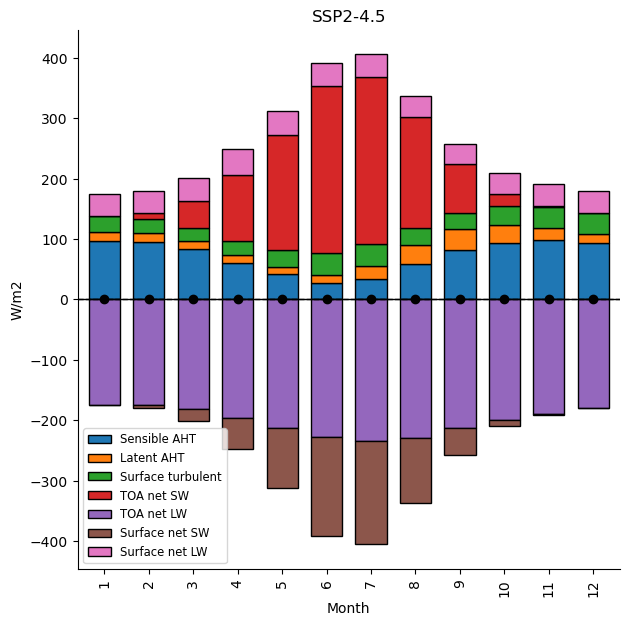

In [29]:
ds_dict = {'SSP2-4.5':Q_ssp245,
          }
    
    
fig, ax = plt.subplots(1, len(ds_dict), figsize = (7, 7))#, sharey=True)
    
i=0
for title in ds_dict:
    ds = ds_dict[title]
    #ax = axs[i]
    #ax = axs
    df = pd.DataFrame({'Month':ds.month.values,
                       'tas':ds.tas.values,
                   'Total HT':ds.Q.values + ds.hfls.values + ds.hfss.values - ds.rsut.values + ds.rsdt.values - ds.rlut.values - ds.rsds.values + ds.rsus.values - ds.rlds.values + ds.rlus.values,
                   'Sensible AHT':ds.Qdry.values,
                   'Latent AHT':ds.Qmoist.values,
                    'Surface turbulent':ds.hfls.values + ds.hfss.values,
                       'TOA net SW': -ds.rsut.values + ds.rsdt.values,
                       'TOA net LW': -ds.rlut.values,
                       'Surface net SW':-ds.rsds.values + ds.rsus.values,
                       'Surface net LW':-ds.rlds.values + ds.rlus.values,
                   #'OHT':ds.hfAtl_66.values 
                   }
                 )#.set_index('Month')
    mean = df['Total HT'].mean()
    df.drop(columns=['Total HT', 'tas']).plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black")
    
    ax.scatter(range(len(df)), df['Total HT'], c='black')
    #ax.plot(range(len(df)), df['tas'], c='red', ls='--')
    ax.set_title(title)
    if i == 0:   
        ax.set_ylabel(units)
    ax.axhline(y=0, c='black', lw=1)
    ax.axhline(y=mean, c='black', lw=1, ls='--')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(fontsize='small', loc='lower left')
    if i > 0:
        ax.get_legend().remove()
        
    i=i+1
#plt.savefig('Figures/main/atmospheric_column_budget_detailed_SSP245.jpg', dpi=400)

3.7508027092677856


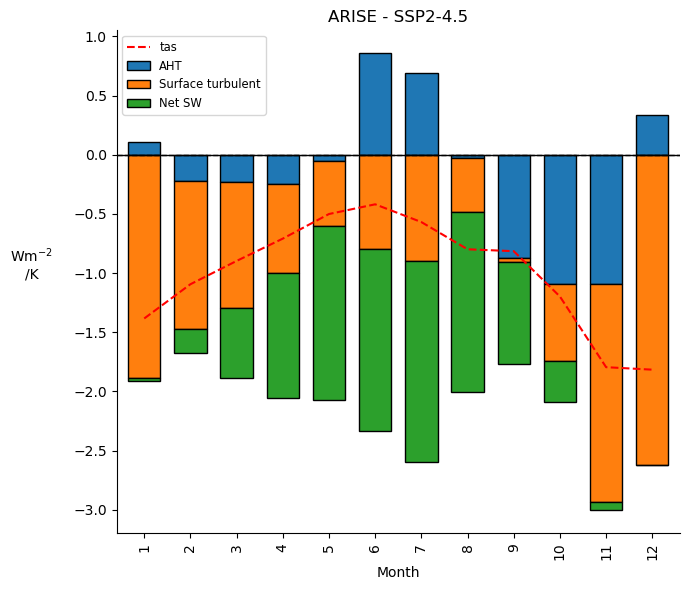

In [30]:
ds_dict = {
           'ARISE - SSP2-4.5': Q_arise - Q_ssp245,
          }
    
    
fig, ax = plt.subplots(1, len(ds_dict), figsize = (7, 6))
    
i=0
for title in ds_dict:
    ds = ds_dict[title]
    arctic_cooling = -ds.tas.mean().item()
    print(arctic_cooling)
    #ax = axs[i]
    #ax = axs
    df = pd.DataFrame({'Month':ds.month.values,
                       'tas':ds.tas.values/arctic_cooling,
                   'Total HT':(ds.Q.values + ds.hfls.values + ds.hfss.values - ds.rsut.values + ds.rsdt.values - ds.rlut.values - ds.rsds.values + ds.rsus.values - ds.rlds.values + ds.rlus.values)/arctic_cooling,
                   'AHT':(ds.Qdry.values+ds.Qmoist.values)/arctic_cooling,
                   #'Latent AHT':ds.Qmoist.values,
                    'Surface turbulent':(ds.hfls.values + ds.hfss.values)/arctic_cooling,
                       'Net SW': (-ds.rsut.values + ds.rsdt.values - ds.rsds.values + ds.rsus.values)/arctic_cooling,
                      # 'Net LW': (-ds.rlut.values - ds.rlds.values + ds.rlus.values)/arctic_cooling,
                       #'Surface net SW':-ds.rsds.values + ds.rsus.values,
                       #'Surface net LW':-ds.rlds.values + ds.rlus.values,
                   #'OHT':ds.hfAtl_66.values 
                   }
                 )#.set_index('Month')
    mean = df['Total HT'].mean()
    df.drop(columns=['Total HT', 'tas']).plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black")
    
    #ax.scatter(range(len(df)), df['Total HT'], c='black')
    ax.plot(range(len(df)), df['tas'], c='red', ls='--')
    ax.set_title(title)
    if i == 0:   
        ax.set_ylabel('Wm$^{-2}$\n/K', rotation=0, labelpad=30)
    ax.axhline(y=0, c='black', lw=1)
    ax.axhline(y=mean, c='black', lw=1, ls='--')
    ax.plot([], [], c='red', ls='--', label='tas')
    ax.legend(fontsize='small', loc='upper left')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    if i > 0:
        ax.get_legend().remove()
    i=i+1
plt.tight_layout()
#plt.savefig('Figures/main/atmospheric_column_budget_by_scenario_noLW.jpg', dpi=400)

In [31]:
## add F and albedo, and save:

def add_extra_variables(ds, scen):

    # add IRF, allsky and clearsky
    ds['IRF_aer'] = ds['rsutaf'] - ds['rsut']  # sign convention here is that more SW to space is a negative forcing
    ds['IRF_aer_cs'] = ds['rsutcsaf'] - ds['rsutcs']

    # add albedo, defined as ratio of reflected up to incident down SW radiation:
    ds['albedo'] = ds['rsus']/ds['rsds']

    # add CRF (cloud radiative forcing)
    ds['CRF'] = -(ds['rsut']+ds['rlut']) - (ds['rsutcs']+ds['rlutcs'])

    ds.to_netcdf('intermediate_outputs/fin/{s}_{l}_{m}.nc'.format(
        s=scen, l=str(min_lat), m=model))
    return ds


ds_ssp245 = add_extra_variables(ds_ssp245, 'ssp245')
ds_arise = add_extra_variables(ds_arise, 'ARISE')